In [2]:
#========================
# SCADA Data_analytics_v1
#========================

In [3]:
# Import libraries

import random
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import sqlite3

In [4]:
# Connect to the database

sqliteConnection = sqlite3.connect('SCADA_Historian.db')

In [5]:
# Read data from sqlite3 to pandas dataframe

df = pd.read_sql_query("SELECT * FROM process_data", sqliteConnection, index_col="ID")
sqliteConnection.close()

In [6]:
print(df)
print(df.info())
print(df.describe())

               timestamp  temperature  pressure  temperature_change  \
ID                                                                    
1    2026-06-11 06:01:00           42      1.55                   0   
2    2026-06-11 06:02:00           42      1.48                   0   
3    2026-06-11 06:03:00           42      1.52                   0   
4    2026-06-11 06:04:00           42      1.43                   0   
5    2026-06-11 06:05:00           42      1.52                   0   
..                   ...          ...       ...                 ...   
362  2026-06-11 12:02:00           18      4.01                   0   
363  2026-06-11 12:03:00           18      4.03                   0   
364  2026-06-11 12:04:00           18      3.99                   0   
365  2026-06-11 12:05:00           16      3.52                  -2   
366  2026-06-11 12:06:00           16      3.28                   0   

     pressure_change  
ID                    
1               0.00  
2      

In [7]:
# Change dataime format

df['timestamp'] = pd.to_datetime(df['timestamp'])

print(df)
print(df.info())
print(df.describe())

              timestamp  temperature  pressure  temperature_change  \
ID                                                                   
1   2026-06-11 06:01:00           42      1.55                   0   
2   2026-06-11 06:02:00           42      1.48                   0   
3   2026-06-11 06:03:00           42      1.52                   0   
4   2026-06-11 06:04:00           42      1.43                   0   
5   2026-06-11 06:05:00           42      1.52                   0   
..                  ...          ...       ...                 ...   
362 2026-06-11 12:02:00           18      4.01                   0   
363 2026-06-11 12:03:00           18      4.03                   0   
364 2026-06-11 12:04:00           18      3.99                   0   
365 2026-06-11 12:05:00           16      3.52                  -2   
366 2026-06-11 12:06:00           16      3.28                   0   

     pressure_change  
ID                    
1               0.00  
2              -0.07

In [8]:
# Filtering datas.

In [9]:
temperature=df["temperature"]

length_tc=len(temperature)-1

df_features_temperature = pd.DataFrame(columns=["timestamp", "temperature_change"])

for o in range(length_tc):
    tc=temperature.iloc[o+1] - temperature.iloc[o]
    current_timestamp_1=df["timestamp"].iloc[o]
    df_features_temperature.loc[o]=[current_timestamp_1, tc]
    

print(df_features_temperature)

              timestamp  temperature_change
0   2026-06-11 06:01:00                   0
1   2026-06-11 06:02:00                   0
2   2026-06-11 06:03:00                   0
3   2026-06-11 06:04:00                   0
4   2026-06-11 06:05:00                   2
..                  ...                 ...
360 2026-06-11 12:01:00                   0
361 2026-06-11 12:02:00                   0
362 2026-06-11 12:03:00                   0
363 2026-06-11 12:04:00                  -2
364 2026-06-11 12:05:00                   0

[365 rows x 2 columns]


In [10]:
pressure=df["pressure"]

length_pc=len(pressure)-1

df_features_pressure = pd.DataFrame(columns=["timestamp", "pressure_change"])

for o in range(length_pc):
    pc=pressure.iloc[o+1] - pressure.iloc[o]
    current_timestamp_2=df["timestamp"].iloc[o]
    df_features_pressure.loc[o]=[current_timestamp_2, pc]
    

print(df_features_pressure)

              timestamp  pressure_change
0   2026-06-11 06:01:00            -0.07
1   2026-06-11 06:02:00             0.04
2   2026-06-11 06:03:00            -0.09
3   2026-06-11 06:04:00             0.09
4   2026-06-11 06:05:00             0.10
..                  ...              ...
360 2026-06-11 12:01:00            -0.04
361 2026-06-11 12:02:00             0.02
362 2026-06-11 12:03:00            -0.04
363 2026-06-11 12:04:00            -0.47
364 2026-06-11 12:05:00            -0.24

[365 rows x 2 columns]


In [11]:
# Visual representation of data.

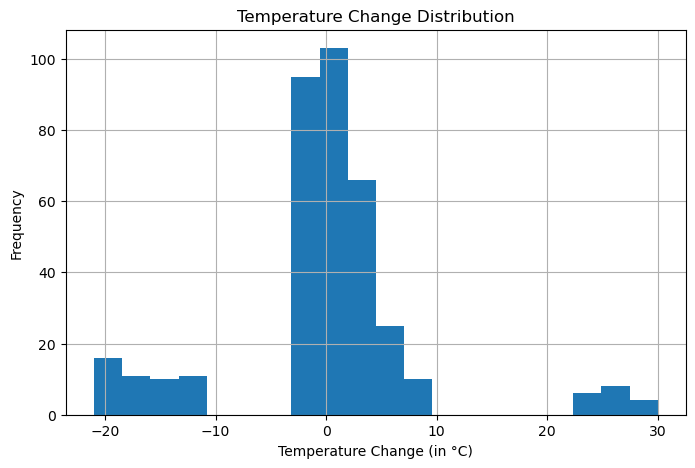

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df_features_temperature["temperature_change"], bins=20)

plt.title('Temperature Change Distribution')
plt.xlabel('Temperature Change (in °C)')
plt.ylabel('Frequency')

plt.grid(True)

plt.show()


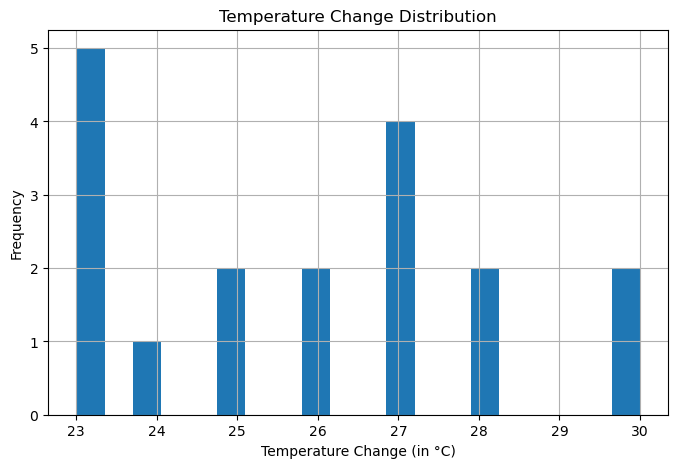

In [13]:
temp_change_plus_20 = df_features_temperature[df_features_temperature["temperature_change"] > 20]

plt.figure(figsize=(8,5))

plt.hist(temp_change_plus_20["temperature_change"], bins=20)

plt.title('Temperature Change Distribution')
plt.xlabel('Temperature Change (in °C)')
plt.ylabel('Frequency')

plt.grid(True)

plt.show()

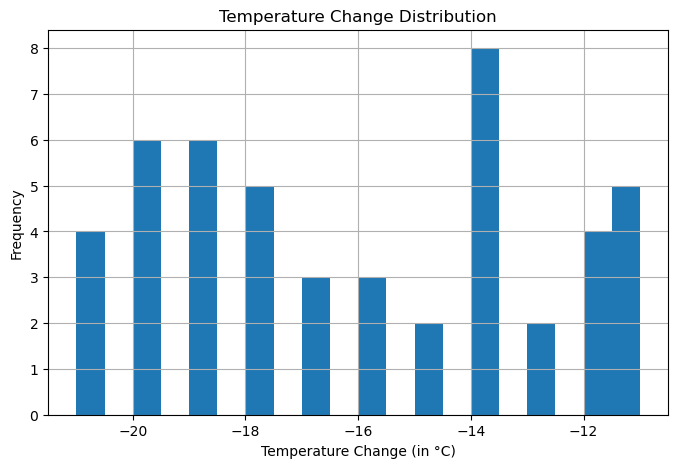

In [14]:
temp_change_minus_10 = df_features_temperature[df_features_temperature["temperature_change"] < -10]

plt.figure(figsize=(8,5))

plt.hist(temp_change_minus_10 ["temperature_change"], bins=20)

plt.title('Temperature Change Distribution')
plt.xlabel('Temperature Change (in °C)')
plt.ylabel('Frequency')

plt.grid(True)

plt.show()

In [19]:
c=df_features_temperature[
    df_features_temperature["temperature_change"] == 23
]
v=df_features_temperature[
    df_features_temperature["temperature_change"] == 27
]
b=df_features_temperature[
    df_features_temperature["temperature_change"] == 30
]
print(c)
print(v)
print(b)

              timestamp  temperature_change
30  2026-06-11 06:31:00                  23
90  2026-06-11 07:31:00                  23
151 2026-06-11 08:32:00                  23
273 2026-06-11 10:34:00                  23
274 2026-06-11 10:35:00                  23
              timestamp  temperature_change
212 2026-06-11 09:33:00                  27
214 2026-06-11 09:35:00                  27
275 2026-06-11 10:36:00                  27
336 2026-06-11 11:37:00                  27
             timestamp  temperature_change
29 2026-06-11 06:30:00                  30
91 2026-06-11 07:32:00                  30


# Summary & Next Steps

## Observation:
### New questions arose based on the histograms.

## Next Step:
### Detailed analysis of identified events in a separate module (event_analysis_v1).

## Module Summary

This module performs the initial exploratory analysis of the SCADA Historian data.

The process data is loaded into Pandas DataFrames, timestamps are converted into a usable datetime format, and temperature and pressure changes are calculated for further analysis.

Histograms are used to examine the distribution of temperature changes and identify unusual or potentially significant patterns. These observations led to the identification of temperature-change groups requiring more detailed investigation.

### Key Observation
The identified temperature changes appear to be parts of larger process cycles rather than independent events.

### Next Step
Continue the detailed investigation in `event_analysis_v1`, where significant temperature changes are grouped into complete process cycles and their characteristics are calculated.